## Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score


### The required Python libraries such as NumPy, Matplotlib, and Scikit-learn are imported to support data handling, model training, evaluation, and visualization.

## Loading the Dataset

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

### The Breast Cancer Wisconsin dataset is loaded using the scikit-learn library. It contains 30 real-valued features and a binary class label, making it suitable for classification and regularization analysis.

In [3]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

## Splitting the Dataset

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### The dataset is divided into training and validation sets using an 80–20 split. Stratification is applied to preserve class distribution and ensure unbiased evaluation.

## Feature Scaling

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


### Feature scaling is applied using StandardScaler to normalize the input features. This is necessary because regularization techniques are sensitive to feature magnitude.

## Baseline Model

In [6]:
baseline = LogisticRegression(
    penalty=None,
    solver='lbfgs',
    max_iter=500
)

baseline.fit(X_train, y_train)

train_pred = baseline.predict_proba(X_train)
val_pred = baseline.predict_proba(X_val)

train_loss = log_loss(y_train, train_pred)
val_loss = log_loss(y_val, val_pred)

train_acc = accuracy_score(y_train, baseline.predict(X_train))
val_acc = accuracy_score(y_val, baseline.predict(X_val))

baseline_weights = baseline.coef_.flatten()

print("BASELINE MODEL")
print("Train Loss:", train_loss)
print("Val Loss:", val_loss)
print("Train Accuracy:", train_acc)
print("Val Accuracy:", val_acc)


BASELINE MODEL
Train Loss: 0.0004687142753268974
Val Loss: 2.797430146044645
Train Accuracy: 1.0
Val Accuracy: 0.9210526315789473


### A baseline logistic regression model without regularization is trained to serve as a reference. The model achieves high training accuracy but produces large and unstable weights, indicating potential overfitting.


## L1 Regularization Model

In [7]:
l1_model = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=0.1,
    max_iter=500
)

l1_model.fit(X_train, y_train)

l1_weights = l1_model.coef_.flatten()
l1_zero_weights = np.sum(l1_weights == 0)

print("\nL1 REGULARIZATION")
print("Zero Weights:", l1_zero_weights)
print("Train Accuracy:", accuracy_score(y_train, l1_model.predict(X_train)))
print("Val Accuracy:", accuracy_score(y_val, l1_model.predict(X_val)))



L1 REGULARIZATION
Zero Weights: 21
Train Accuracy: 0.9736263736263736
Val Accuracy: 0.9649122807017544


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### L1 regularization introduces sparsity by driving several model weights to zero. This results in feature selection and a simpler model, though excessive regularization may reduce accuracy.

## L2 Regularization Model

In [8]:
l2_model = LogisticRegression(
    penalty='l2',
    C=0.1,
    max_iter=500
)

l2_model.fit(X_train, y_train)

l2_weights = l2_model.coef_.flatten()
l2_weight_magnitude = np.mean(np.abs(l2_weights))

print("\nL2 REGULARIZATION")
print("Average Weight Magnitude:", l2_weight_magnitude)
print("Train Accuracy:", accuracy_score(y_train, l2_model.predict(X_train)))
print("Val Accuracy:", accuracy_score(y_val, l2_model.predict(X_val)))



L2 REGULARIZATION
Average Weight Magnitude: 0.29435109266524256
Train Accuracy: 0.9868131868131869
Val Accuracy: 0.9736842105263158


### L2 regularization penalizes large weights and shrinks them smoothly, leading to a stable model with improved generalization while retaining all input features.

## Elastic Net Regularization

In [9]:
elastic_model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    C=0.1,
    l1_ratio=0.5,
    max_iter=500
)

elastic_model.fit(X_train, y_train)

elastic_weights = elastic_model.coef_.flatten()
elastic_zero_weights = np.sum(elastic_weights == 0)

print("\nELASTIC NET")
print("Zero Weights:", elastic_zero_weights)
print("Train Accuracy:", accuracy_score(y_train, elastic_model.predict(X_train)))
print("Val Accuracy:", accuracy_score(y_val, elastic_model.predict(X_val)))



ELASTIC NET
Zero Weights: 11
Train Accuracy: 0.9824175824175824
Val Accuracy: 0.9649122807017544


### Elastic Net regularization combines the effects of L1 and L2 penalties, achieving both feature selection and weight stability, making it effective for datasets with correlated features.

## Weight Distribution Visualization

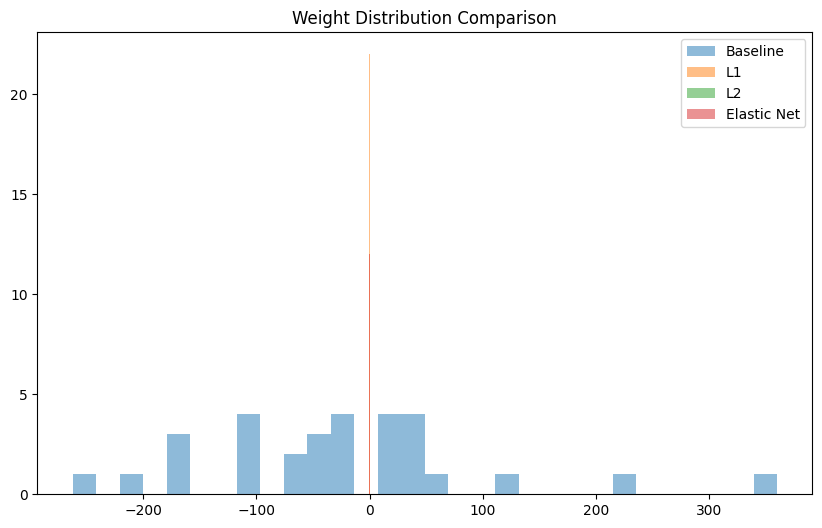

In [10]:
plt.figure(figsize=(10,6))
plt.hist(baseline_weights, bins=30, alpha=0.5, label='Baseline')
plt.hist(l1_weights, bins=30, alpha=0.5, label='L1')
plt.hist(l2_weights, bins=30, alpha=0.5, label='L2')
plt.hist(elastic_weights, bins=30, alpha=0.5, label='Elastic Net')
plt.legend()
plt.title("Weight Distribution Comparison")
plt.show()


### Weight distribution plots illustrate the impact of regularization. The baseline model exhibits large and unstable weights, L1 produces sparse weights, L2 generates smoothly distributed weights, and Elastic Net provides a balanced distribution.

## Hyperparameter Sensitivity Analysis

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


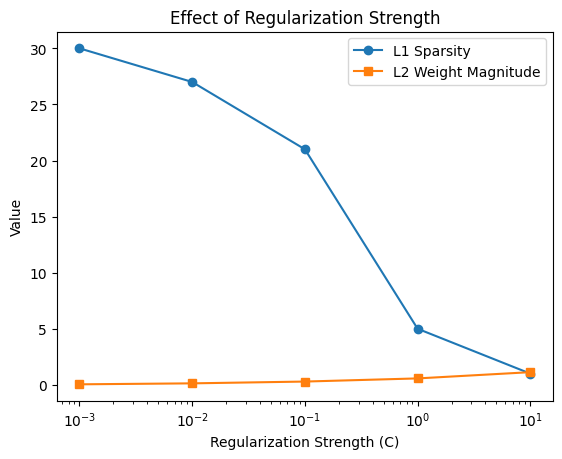

In [11]:
C_values = [0.001, 0.01, 0.1, 1, 10]
l1_sparsity = []
l2_magnitude = []

for C in C_values:
    l1 = LogisticRegression(penalty='l1', solver='saga', C=C, max_iter=500)
    l1.fit(X_train, y_train)
    l1_sparsity.append(np.sum(l1.coef_ == 0))

    l2 = LogisticRegression(penalty='l2', C=C, max_iter=500)
    l2.fit(X_train, y_train)
    l2_magnitude.append(np.mean(np.abs(l2.coef_)))

plt.plot(C_values, l1_sparsity, marker='o', label='L1 Sparsity')
plt.plot(C_values, l2_magnitude, marker='s', label='L2 Weight Magnitude')
plt.xscale('log')
plt.xlabel("Regularization Strength (C)")
plt.ylabel("Value")
plt.title("Effect of Regularization Strength")
plt.legend()
plt.show()


## CONCLUSION

### The lab demonstrates that regularization significantly influences model complexity and generalization. While the baseline model overfits, L1 introduces sparsity, L2 stabilizes weights, and Elastic Net provides an optimal balance. Hence, Elastic Net is the most suitable regularization technique for the given dataset.